# 99 LSTM Model Testing

## Imports

In [596]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import warnings

## Data Retrieval (1-minute failed from yfinance)
We attempted to retrieve 1-minute data from yfinance, but we were unable to do so successfully (even for a short time period)

In [6]:
# Set Scope of Date
start_date_analyzed = '2021-01-01'
end_date_analyzed = '2025-01-01'

# Retrieve S&P 500 tickers
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
tickers = sp500_tables[0].Symbol  # Storing just the symbols into a list
tickers_changed = sp500_tables[1]  # Including the changed tickers as well to remove survivorship bias

# Getting only the added and removed tickers
tickers_added = tickers_changed[pd.to_datetime(tickers_changed.Date.Date) >= start_date_analyzed].Added
tickers_removed = tickers_changed[pd.to_datetime(tickers_changed.Date.Date) >= start_date_analyzed].Removed

# Removing the additional added tickers
tickers = tickers[~(tickers.isin(tickers_added.Ticker))]

# Appending the removed tickers
tickers = pd.concat([tickers, tickers_removed.Ticker], ignore_index=True)

# Dropping any NA values
tickers = tickers.dropna()

# Dropping duplicates
tickers = tickers.drop_duplicates()

# Resetting the index
tickers = tickers.reset_index(drop = True)

# Filtering out problematic tickers
problematic_tickers = ['BF.B', 'BRK.B', 'GEV', 'SOLV', 'SW', 'VLTO']
filtered_tickers = [ticker for ticker in tickers if ticker not in problematic_tickers]

len(filtered_tickers)

508

In [3]:
# One note: don't scrap too many times in a row from Yahoo Finance, or they might block you

In [8]:
# Getting Data for S&P500 Stocks
multi_data = yf.download(filtered_tickers, period='max', interval='1m')

# NOTE: there will be missing stocks because Yahoo Finance has delisted some of the stocks that went out of the S&P500 (like SIVB)
multi_data

[                       1%                       ]  5 of 508 completedFailed to get ticker 'FRC' reason: Expecting value: line 1 column 1 (char 0)
[***                    7%                       ]  38 of 508 completedFailed to get ticker 'ALXN' reason: Expecting value: line 1 column 1 (char 0)
[****                   9%                       ]  48 of 508 completedFailed to get ticker 'PBCT' reason: Expecting value: line 1 column 1 (char 0)
[*********             18%                       ]  93 of 508 completedFailed to get ticker 'HFC' reason: Expecting value: line 1 column 1 (char 0)
[*********             19%                       ]  98 of 508 completedFailed to get ticker 'ATVI' reason: Expecting value: line 1 column 1 (char 0)
[************          26%                       ]  134 of 508 completedFailed to get ticker 'ABMD' reason: Expecting value: line 1 column 1 (char 0)
[***************       31%                       ]  155 of 508 completedFailed to get ticker 'FBHS' reason: 

Empty DataFrame
Columns: [(Adj Close, A), (Adj Close, AAL), (Adj Close, AAP), (Adj Close, AAPL), (Adj Close, ABBV), (Adj Close, ABMD), (Adj Close, ABT), (Adj Close, ACN), (Adj Close, ADBE), (Adj Close, ADI), (Adj Close, ADM), (Adj Close, ADP), (Adj Close, ADSK), (Adj Close, AEE), (Adj Close, AEP), (Adj Close, AES), (Adj Close, AFL), (Adj Close, AIG), (Adj Close, AIZ), (Adj Close, AJG), (Adj Close, AKAM), (Adj Close, ALB), (Adj Close, ALGN), (Adj Close, ALK), (Adj Close, ALL), (Adj Close, ALLE), (Adj Close, ALXN), (Adj Close, AMAT), (Adj Close, AMCR), (Adj Close, AMD), (Adj Close, AME), (Adj Close, AMGN), (Adj Close, AMP), (Adj Close, AMT), (Adj Close, AMTM), (Adj Close, AMZN), (Adj Close, ANET), (Adj Close, ANSS), (Adj Close, AON), (Adj Close, AOS), (Adj Close, APA), (Adj Close, APD), (Adj Close, APH), (Adj Close, APTV), (Adj Close, ARE), (Adj Close, ATO), (Adj Close, ATVI), (Adj Close, AVB), (Adj Close, AVGO), (Adj Close, AVY), (Adj Close, AWK), (Adj Close, AXP), (Adj Close, AZO), (Adj Close, BA), (Adj Close, BAC), (Adj Close, BALL), (Adj Close, BAX), (Adj Close, BBWI), (Adj Close, BBY), (Adj Close, BDX), (Adj Close, BEN), (Adj Close, BIIB), (Adj Close, BIO), (Adj Close, BK), (Adj Close, BKNG), (Adj Close, BKR), (Adj Close, BLK), (Adj Close, BMY), (Adj Close, BR), (Adj Close, BSX), (Adj Close, BWA), (Adj Close, BXP), (Adj Close, C), (Adj Close, CAG), (Adj Close, CAH), (Adj Close, CARR), (Adj Close, CAT), (Adj Close, CB), (Adj Close, CBOE), (Adj Close, CBRE), (Adj Close, CCI), (Adj Close, CCL), (Adj Close, CDNS), (Adj Close, CDW), (Adj Close, CE), (Adj Close, CERN), (Adj Close, CF), (Adj Close, CFG), (Adj Close, CHD), (Adj Close, CHRW), (Adj Close, CHTR), (Adj Close, CI), (Adj Close, CINF), (Adj Close, CL), (Adj Close, CLX), (Adj Close, CMA), (Adj Close, CMCSA), (Adj Close, CME), (Adj Close, CMG), (Adj Close, CMI), ...]
Index: []

[0 rows x 3048 columns]

## LSTM Testing

From the following link: https://www.geeksforgeeks.org/long-short-term-memory-lstm-rnn-in-tensorflow/

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [28]:
# Getting data and scaling it
data = pd.read_csv('monthly_milk_production.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
production = data['Production'].astype(float).values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(production)

In [60]:
scaled_data.shape

(168, 1)

In [56]:
window_size = 12
X = []
y = []
target_dates = data.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [51]:
X[0]

array([0.08653846, 0.01923077, 0.20913462, 0.24759615, 0.41826923,
       0.34615385, 0.20913462, 0.11057692, 0.03605769, 0.05769231,
       0.        , 0.06971154])

In [52]:
X[1]

array([0.01923077, 0.20913462, 0.24759615, 0.41826923, 0.34615385,
       0.20913462, 0.11057692, 0.03605769, 0.05769231, 0.        ,
       0.06971154, 0.11298077])

In [57]:
X_train.shape

(124, 12, 1)

In [302]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [303]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.1801 - val_loss: 0.0296
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0393 - val_loss: 0.0468
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0317 - val_loss: 0.0609
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0347 - val_loss: 0.0599
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0292 - val_loss: 0.0293
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0279 - val_loss: 0.0287
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0301 - val_loss: 0.0265
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0252 - val_loss: 0.0364
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0266 - val_loss: 0.0377
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0270 - val_loss: 0.0270
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0253 - val_loss: 0.0253
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0254 - val_lo

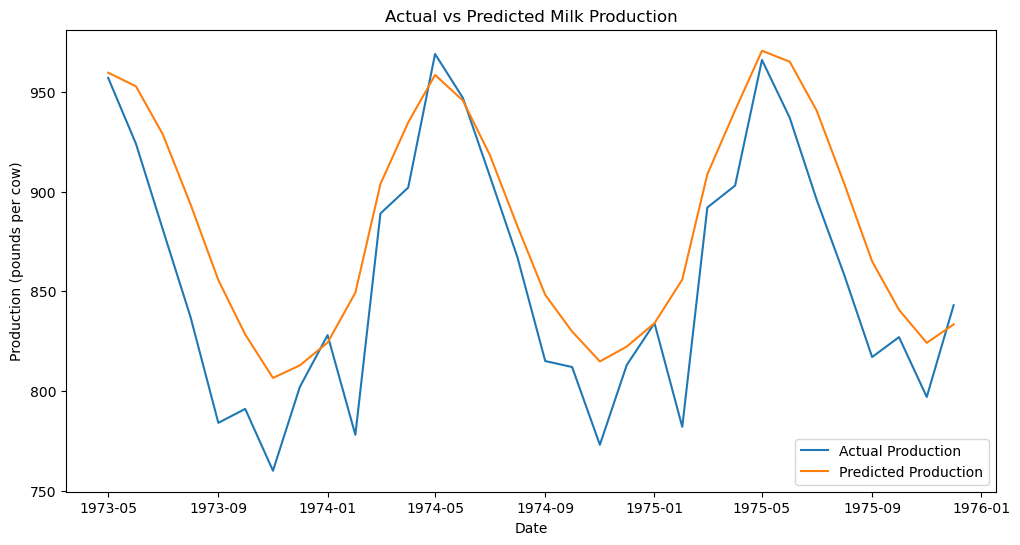

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, predictions, label='Predicted Production')
plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.legend()
plt.show()

# Conclusions from LSTM Model Testing
This initial testing was crucial for our understanding of the LSTM model. We saw the need to convert our data into a series format, and we saw how important they were for future predictions. We will attempt integrating something similar when we actually work with our stock data.